# Vision Transformers

## Install packages

In [1]:
import torch 
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets

In [28]:
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.12.0
Torchvision version: 0.27.0


In [13]:
from torch.utils.data import DataLoader

In [2]:
import torchinfo as ti

In [4]:
from pathlib import Path
import os 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Pandas version: 3.0.3
Numpy version: 2.4.6


In [33]:
device = "cpu"

## Path to the data

In [34]:
image_path = Path(".") / "data" / "pizza_steak_suchi"

In [35]:
train_dir = image_path / "train"
test_dir = image_path / "test"

## Transforms, Dataset and DataLoaders

In [36]:
# Transform
transform_train = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

We use the `ImageFolder` class because the structure of our data folder is such that it fits the class requirements

In [ ]:
# Dataset 
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_train)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform_test)

In [38]:
# DataLoader

train_dataloader = DataLoader(dataset=train_dataset, 
                              batch_size=32, 
                              shuffle=True, 
                              pin_memory=True, 
                              prefetch_factor= 2,
                              num_workers=os.cpu_count()-4
                              )

test_dataloader = DataLoader(dataset=test_dataset, 
                             batch_size=32, 
                             pin_memory=True, 
                             prefetch_factor=2, 
                             num_workers=os.cpu_count()-4)

In [39]:
img, label = next(iter(train_dataloader))

/Users/maximecollet/Desktop/PyTorch/ZTM_nb/Learning_PyTorch/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [40]:
image, label = img[0], label[0]

In [41]:
classes = train_dataset.classes

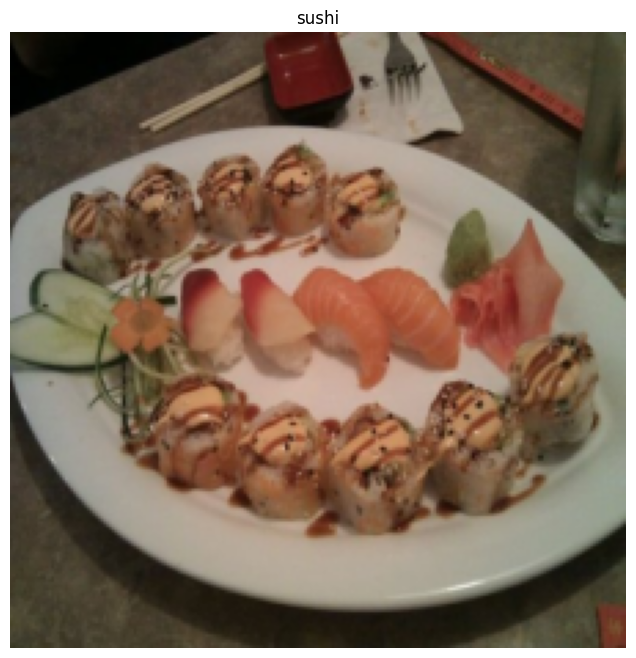

In [42]:
plt.figure(figsize=(12,8))
plt.imshow(image.permute(1,2,0)) # plt.imshow() takes inputs like this: (H,W,C) and not (C, H, W)
plt.title(f"{classes[label]}")
plt.axis(False)
plt.show()

### Equation 1: Split data into patches and creating the class, position and patch embedding

Layer = input -> function -> output

what is the input shape: single image of size `(224,224,3)`

what is the output shape

In [43]:
# create example values

height = 224
width = 224
color_channels = 3
patch_size = 16

# number of patches

number_of_patches = int((height*width)/patch_size**2)
number_of_patches

196

In [44]:
# inptu shape

embedding_layer_input_shape = (height, width, color_channels)

embedding_layer_output_shape = (number_of_patches, patch_size**2*color_channels)

print(f"Input shape:{embedding_layer_input_shape}")
print(f"Output shape:{embedding_layer_output_shape}")

Input shape:(224, 224, 3)
Output shape:(196, 768)


In [48]:
# Turning a single image into patches

img_permuted = image.permute(1,2,0)

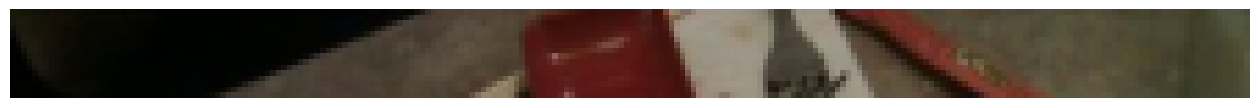

In [54]:
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(img_permuted[:16,:,:])
plt.axis(False)
plt.show()

In [56]:
img_size = 224
patch_size = 16
n_patch = int(img_size/patch_size)

In [68]:
img_permuted.shape

torch.Size([224, 224, 3])

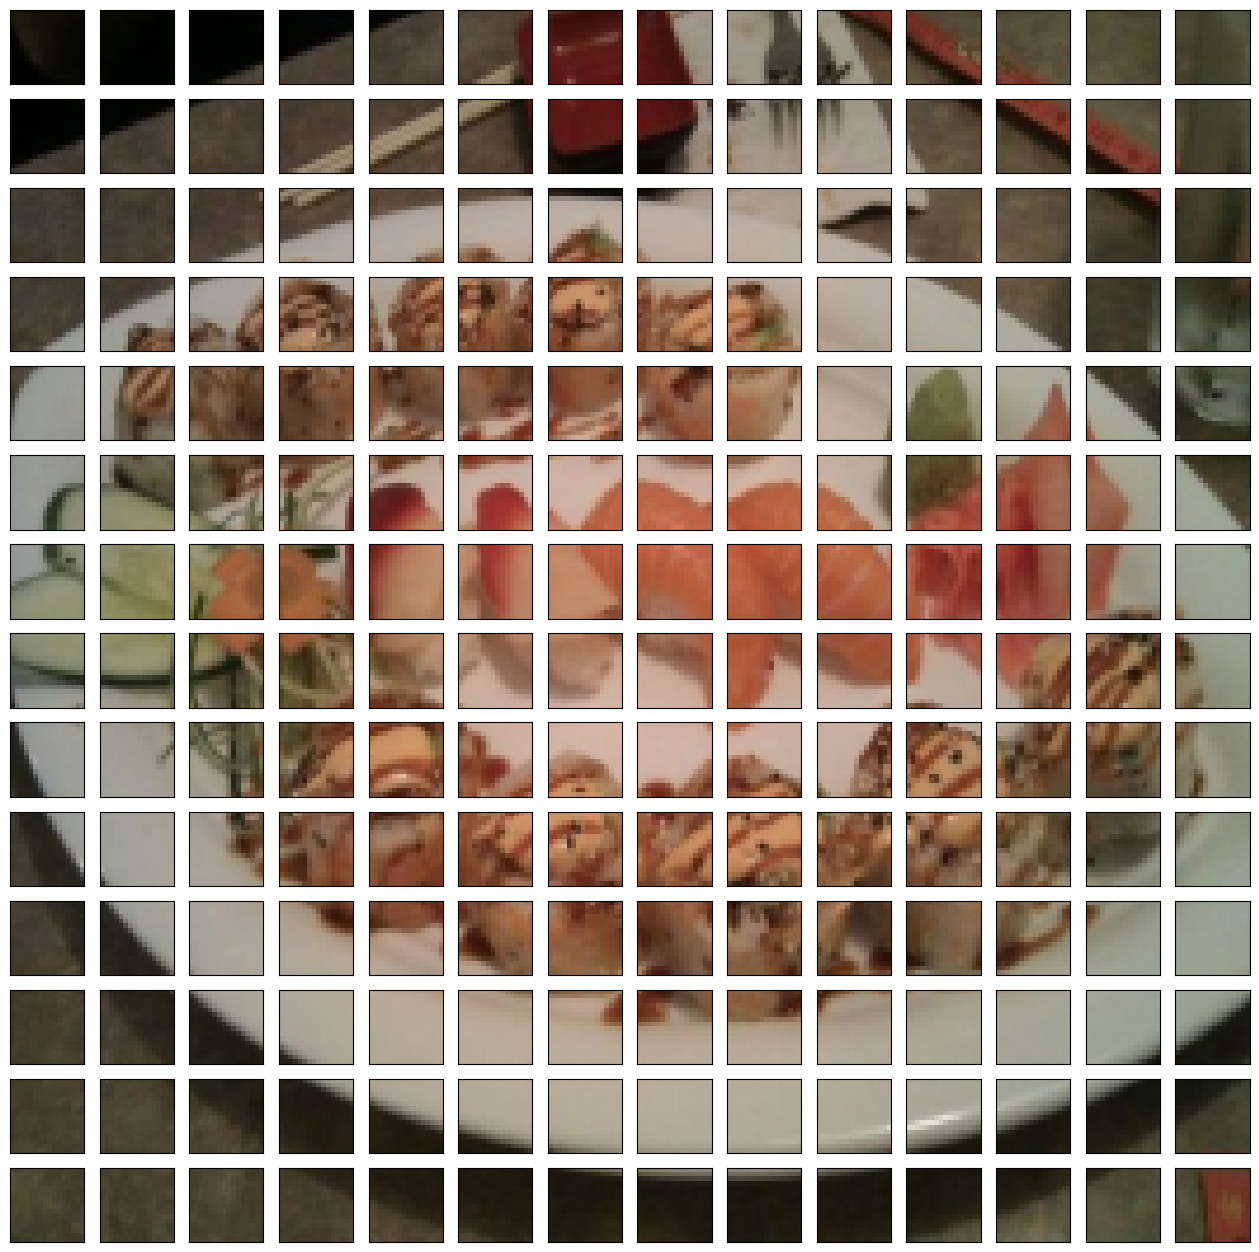

In [74]:
# setup code to split into patches
fig, ax = plt.subplots(nrows=n_patch, ncols=n_patch, figsize=(patch_size, patch_size))
for i, patch_i in enumerate(range(0,img_size, patch_size)):
    for j, patch_j in enumerate(range(0,img_size,patch_size)):
        ax[i,j].imshow(img_permuted[patch_i:patch_i+patch_size, patch_j:patch_j+patch_size, :])
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])